In [240]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('monthly_sum_UL.csv')

# Convert the 'month' column to datetime
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Add 1 month before the first month in the DataFrame
start_date = df['month'].min()
extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')
extra_data = pd.DataFrame({'month': extra_months, 'ordered_quantity': np.nan})
df = pd.concat([extra_data, df])

# Replace outliers
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 0.5 * IQR
    upper_bound = Q3 + 0.5 * IQR
    df[column] = df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else np.nan)
    return df

df = replace_outliers(df, 'ordered_quantity')

# Compute median for each month
monthly_medians = df.groupby(df['month'].dt.month)['ordered_quantity'].median()

# Function to impute missing values based on month
def impute_missing_values_by_month(df, column):
    df[column] = df.apply(lambda row: monthly_medians[row['month'].month] if pd.isna(row[column]) else row[column], axis=1)
    return df

# Impute missing values
df = impute_missing_values_by_month(df, 'ordered_quantity')

# Save the modified DataFrame
df.to_csv('monthly_sum_UL_modified.csv', index=False)

print(df)

# Read and display the modified file
df_modified = pd.read_csv('monthly_sum_UL_modified.csv', parse_dates=['month'], index_col=['month'])
print(df_modified.head())


        month  ordered_quantity
0  2021-06-30        16317715.5
1  2021-07-31        16227075.0
2  2021-08-31        14097700.0
3  2021-09-30        16985200.0
0  2021-10-01        13641869.0
1  2021-11-01        13528620.0
2  2021-12-01        13698500.0
3  2022-01-01        13012300.0
4  2022-02-01        13692781.0
5  2022-03-01        15013380.0
6  2022-04-01        12806322.0
7  2022-05-01        13799937.0
8  2022-06-01        17503525.0
9  2022-07-01        16227075.0
10 2022-08-01        14097700.0
11 2022-09-01        16985200.0
12 2022-10-01        11905300.0
13 2022-11-01        12955600.0
14 2022-12-01        13364275.0
15 2023-01-01        12635700.0
16 2023-02-01        11679500.0
17 2023-03-01        13038297.0
18 2023-04-01        14065166.0
19 2023-05-01        13808906.0
20 2023-06-01        15131906.0
21 2023-07-01        16227075.0
22 2023-08-01        14097700.0
23 2023-09-01        16985200.0
24 2023-10-01        15378438.0
25 2023-11-01        15552900.0
26 2023-

C:\Users\user\AppData\Local\Temp\ipykernel_40440\774892568.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')


In [241]:

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


print("ULL")


df = pd.read_csv('monthly_sum_UL_modified.csv', parse_dates = ['month'], index_col = ['month'])
 
df.head()




ULL


,ordered_quantity
month,
2021-06-30,16317715.5
2021-07-31,16227075.0
2021-08-31,14097700.0
2021-09-30,16985200.0
2021-10-01,13641869.0


Statistiques ADF : -3.557842360421969
p-value : 0.006620065094092403
Valeurs Critiques :
	1%: -3.661428725118324
	5%: -2.960525341210433
	10%: -2.6193188033298647


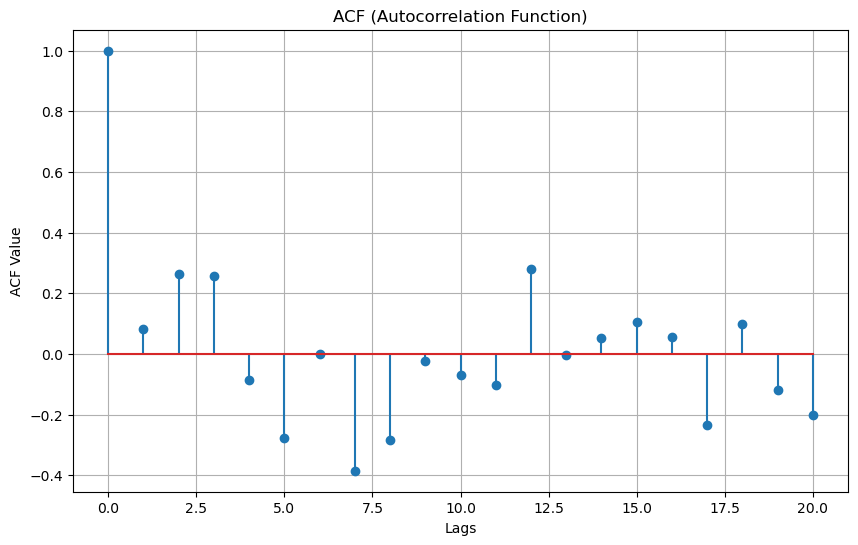

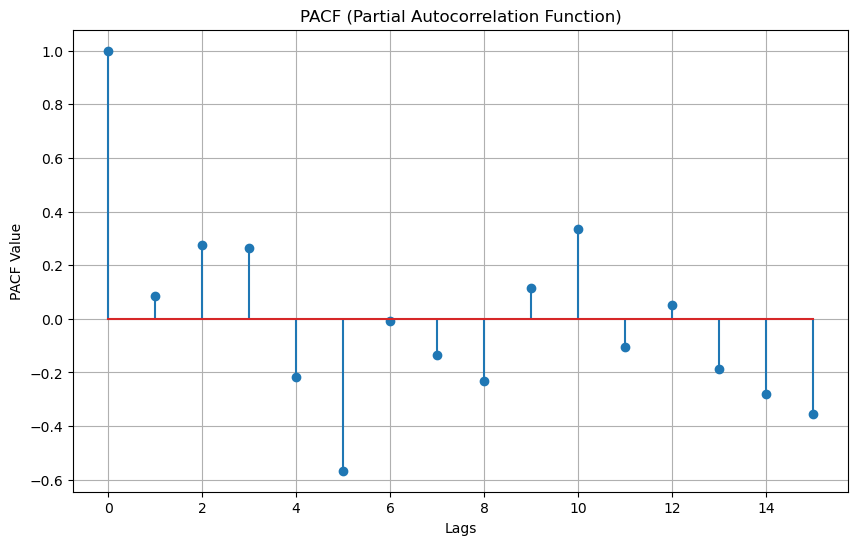

In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Vérification de la stationnarité avec le test ADF
result = adfuller(df['ordered_quantity'])

print('Statistiques ADF : {}'.format(result[0]))
print('p-value : {}'.format(result[1]))
print('Valeurs Critiques :')
for key, value in result[4].items():
    print('\t{}: {}'.format(key, value))

# Affichage de l'ACF (Autocorrelation Function)
acf_values = acf(df['ordered_quantity'], nlags=20)  # Ajustez nlags selon la taille de vos données

# Tracer l'ACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_values)), acf_values, use_line_collection=True)
plt.title('ACF (Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('ACF Value')
plt.grid()
plt.show()

# Affichage de la PACF (Partial Autocorrelation Function)
# Ajustez nlags pour qu'il soit inférieur à 50 % de la taille de votre échantillon
pacf_values = pacf(df['ordered_quantity'], nlags=15)

# Tracer la PACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(pacf_values)), pacf_values, use_line_collection=True)
plt.title('PACF (Partial Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('PACF Value')
plt.grid()
plt.show()


In [243]:
    
#############################log application ##########################

df_log = np.log(df)
df_log.head()


,ordered_quantity
month,
2021-06-30,16.607762
2021-07-31,16.602192
2021-08-31,16.461522
2021-09-30,16.647853
2021-10-01,16.428654


MAE: 14693355.05568203
MSE: 215945379016553.06
RMSE: 14695080.09561544
R²: -1.7506694958448972e+16
                 Date      Forecast type
2023-10-01 2024-06-01  1.467701e+07   DS
2023-11-01 2024-07-01  1.520509e+07   DS
2023-12-01 2024-08-01  1.486546e+07   DS
2024-01-01 2024-09-01  1.468413e+07   DS
2024-02-01 2024-10-01  1.458654e+07   DS
2024-03-01 2024-11-01  1.453380e+07   DS
2024-04-01 2024-12-01  1.450522e+07   DS
2024-05-01 2025-01-01  1.448972e+07   DS
2024-06-01 2025-02-01  1.448130e+07   DS
2024-07-01 2025-03-01  1.447673e+07   DS
2024-08-01 2025-04-01  1.447425e+07   DS
2024-09-01 2025-05-01  1.447290e+07   DS
2024-10-01 2025-06-01  1.447217e+07   DS
2024-11-01 2025-07-01  1.447177e+07   DS
2024-12-01 2025-08-01  1.447156e+07   DS
2025-01-01 2025-09-01  1.447144e+07   DS
2025-02-01 2025-10-01  1.447138e+07   DS
2025-03-01 2025-11-01  1.447134e+07   DS
2025-04-01 2025-12-01  1.447132e+07   DS
2025-05-01 2026-01-01  1.447131e+07   DS


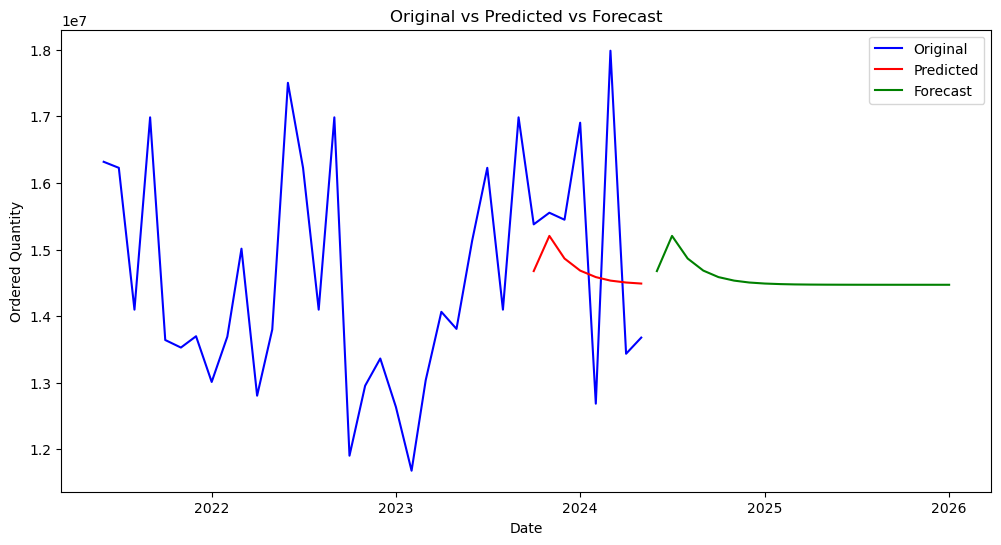

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Décomposer la série saisonnière
decomposition = seasonal_decompose(df_log)

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle ARIMA sur l'ensemble d'apprentissage
model = ARIMA(train_data, order=(1,0,2))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Convertir les prédictions en antilogarithme
predictions_antilog = np.exp(predictions)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions_antilog)
mse = mean_squared_error(test_data, predictions_antilog)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions_antilog)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'UL'

# Afficher le DataFrame avec les prédictions en antilogarithme et la colonne "type"
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, np.exp(df_log['ordered_quantity']), label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions_antilog, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [ ]:
################################    modele a retenir #########################################

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed t

MAE: 0.11241622825137565
MSE: 0.016954939849345284
RMSE: 0.13021113565799694
R²: -0.3745372155362763
            lower ordered_quantity  upper ordered_quantity   Forecast type
2024-06-01               16.369777               16.504007  16.436892   DS
2024-07-01               16.332979               16.481414  16.407196   DS
2024-08-01               16.374342               16.521807  16.448074   DS
2024-09-01               16.329891               16.505955  16.417923   DS
2024-10-01               16.336532               16.528167  16.432350   DS
2024-11-01               16.424162               16.634457  16.529310   DS
2024-12-01               16.262983               16.498257  16.380620   DS
2025-01-01               16.332604               16.570422  16.451513   DS
2025-02-01               16.574829               16.815386  16.695107   DS
2025-03-01               16.468740               16.720967  16.594854   DS
2025-04-01               16.321324               16.578276  16.449800   DS

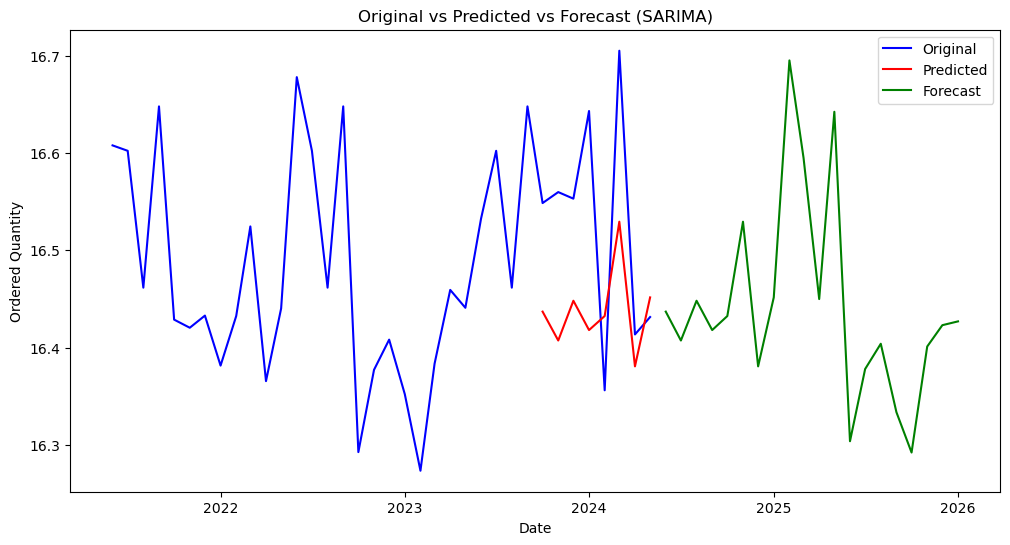

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle SARIMA sur l'ensemble d'apprentissage
# (p,d,q) x (P,D,Q,s) où s est la périodicité saisonnière, par exemple 12 pour les données mensuelles
model = SARIMAX(train_data, order=(6, 0, 6), seasonal_order=(6, 0, 6, 12))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions)
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.get_forecast(steps=20)
forecast_df = forecast.conf_int()
forecast_df['Forecast'] = forecast.predicted_mean

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_df.index = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'UL'

# Afficher le DataFrame avec les prédictions
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, df_log['ordered_quantity'], label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [282]:
import numpy as np
import pandas as pd
import pyodbc

# Assuming results and df_log are already defined in your session

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)

# Flatten the forecast if it's not 1D
if forecast.ndim > 1:
    forecast = forecast.flatten()

# Convertir les prédictions en antilogarithme
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "UL"
forecast_df['type'] = 'UL'

# Afficher le DataFrame
print(forecast_df)

# SQL Server connection details (ensure they are correct)
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Establish connection
conn = pyodbc.connect(f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password}')
cursor = conn.cursor()

# Backup the existing table if it exists
cursor.execute("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME = 'dim_pred_orders_UL'")
table_exists = cursor.fetchone()[0]

if table_exists:
    # Backup existing table
    cursor.execute("SELECT * INTO dim_pred_orders_UL_backup FROM dim_pred_orders_UL")
    cursor.execute("DROP TABLE dim_pred_orders_UL")
    print("Existing table backed up and dropped successfully.")

# Create new table for forecast data
create_table_query = '''
CREATE TABLE dim_pred_orders_UL (
    Date DATE,
    Forecast FLOAT,
    type NVARCHAR(50),
    PRIMARY KEY (Date, Forecast, type)
)
'''
cursor.execute(create_table_query)
print("New table created successfully.")

# Insert forecast data
data_to_insert = [tuple(row) for row in forecast_df.values]
insert_query = '''
INSERT INTO dim_pred_orders_UL (Date, Forecast, type)
VALUES (?, ?, ?)
'''
cursor.executemany(insert_query, data_to_insert)

# Commit the transaction and close the connection
conn.commit()
conn.close()

print("Forecast data successfully inserted into dim_pred_orders_UL.")


                 Date      Forecast type
2023-10-01 2024-06-01  1.375471e+07   UL
2023-11-01 2024-07-01  1.335226e+07   UL
2023-12-01 2024-08-01  1.390939e+07   UL
2024-01-01 2024-09-01  1.349626e+07   UL
2024-02-01 2024-10-01  1.369237e+07   UL
2024-03-01 2024-11-01  1.508649e+07   UL
2024-04-01 2024-12-01  1.300208e+07   UL
2024-05-01 2025-01-01  1.395730e+07   UL
2024-06-01 2025-02-01  1.780709e+07   UL
2024-07-01 2025-03-01  1.610844e+07   UL
2024-08-01 2025-04-01  1.393341e+07   UL
2024-09-01 2025-05-01  1.689137e+07   UL
2024-10-01 2025-06-01  1.203896e+07   UL
2024-11-01 2025-07-01  1.296642e+07   UL
2024-12-01 2025-08-01  1.330782e+07   UL
2025-01-01 2025-09-01  1.240386e+07   UL
2025-02-01 2025-10-01  1.189998e+07   UL
2025-03-01 2025-11-01  1.327004e+07   UL
2025-04-01 2025-12-01  1.356433e+07   UL
2025-05-01 2026-01-01  1.361736e+07   UL
New table created successfully.
Forecast data successfully inserted into dim_pred_orders_UL.


13:43:07 - cmdstanpy - INFO - Chain [1] start processing
13:43:15 - cmdstanpy - INFO - Chain [1] done processing


           ds       yhat  yhat_lower  yhat_upper
0  2021-06-01  16.607766   16.607766   16.607766
1  2021-07-01  16.602190   16.602190   16.602190
2  2021-08-01  16.461521   16.461521   16.461521
3  2021-09-01  16.647853   16.647853   16.647853
4  2021-10-01  16.428656   16.428656   16.428656
5  2021-11-01  16.420322   16.420322   16.420322
6  2021-12-01  16.432796   16.432796   16.432796
7  2022-01-01  16.381404   16.381404   16.381404
8  2022-02-01  16.432377   16.432377   16.432377
9  2022-03-01  16.524455   16.524455   16.524455
10 2022-04-01  16.365448   16.365448   16.365448
11 2022-05-01  16.440175   16.440175   16.440175
12 2022-06-01  16.677917   16.677917   16.677917
13 2022-07-01  16.602189   16.602189   16.602189
14 2022-08-01  16.461521   16.461521   16.461521
15 2022-09-01  16.647852   16.647852   16.647852
16 2022-10-01  16.292496   16.292496   16.292496
17 2022-11-01  16.377042   16.377042   16.377042
18 2022-12-01  16.408094   16.408094   16.408094
19 2023-01-01  16.35

C:\Users\user\AppData\Roaming\Python\Python39\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


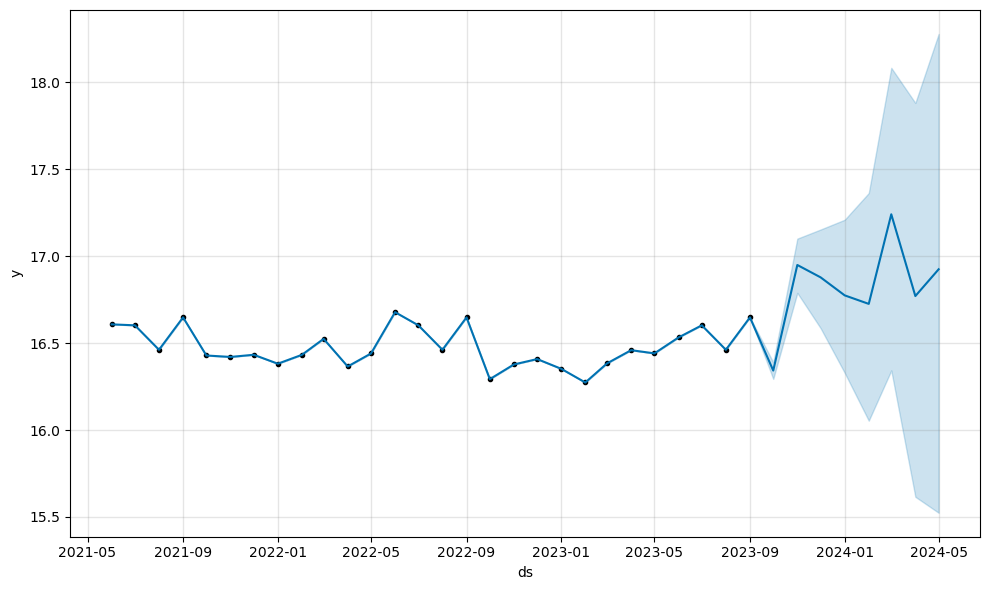

C:\Users\user\AppData\Roaming\Python\Python39\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead 

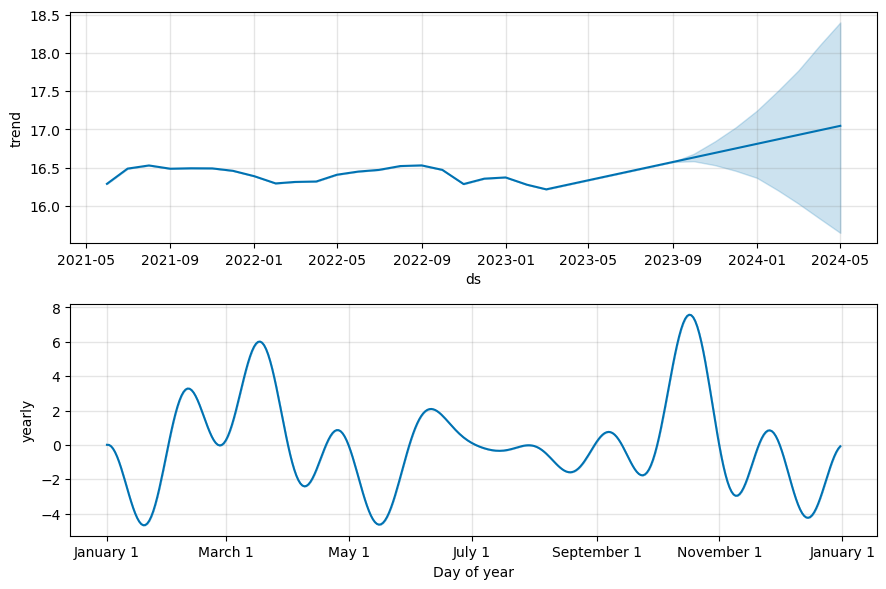

In [254]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Préparer les données pour Prophet
df_prophet = df_log.reset_index()
df_prophet.rename(columns={'month': 'ds', 'ordered_quantity': 'y'}, inplace=True)

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.8
split_index = int(len(df_prophet) * train_size)
train_data = df_prophet.iloc[:split_index]
test_data = df_prophet.iloc[split_index:]

# Créer le modèle Prophet
model = Prophet()

# Ajuster le modèle aux données d'entraînement
model.fit(train_data)

# Créer un dataframe pour les prévisions futures
future = model.make_future_dataframe(periods=len(test_data), freq='MS')

# Faire les prévisions
forecast = model.predict(future)

# Afficher les prévisions
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']])

# Calcul des métriques d'évaluation
# Extraire les valeurs prédites et réelles correspondant à la période de test
predictions = forecast['yhat'].iloc[-len(test_data):].values
actual_values = test_data['y'].values

mae = mean_absolute_error(actual_values, predictions)
mse = mean_squared_error(actual_values, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actual_values, predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Tracer les résultats
fig = model.plot(forecast)
plt.show()

# Si vous voulez voir les composants individuels (tendances, saisonnalité, etc.)
fig2 = model.plot_components(forecast)
plt.show()


In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Créer des variables retardées (lags)
df_lagged = df_log.copy()
for lag in range(1, 5):  # Ajustez le nombre de lags selon vos besoins
    df_lagged[f'lag_{lag}'] = df_lagged['ordered_quantity'].shift(lag)

# Supprimer les lignes avec des valeurs NaN
df_lagged = df_lagged.dropna()

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.8
split_index = int(len(df_lagged) * train_size)
train_data = df_lagged.iloc[:split_index]
test_data = df_lagged.iloc[split_index:]

# Séparer les features et la target
X_train = train_data.drop('ordered_quantity', axis=1)
y_train = train_data['ordered_quantity']
X_test = test_data.drop('ordered_quantity', axis=1)
y_test = test_data['ordered_quantity']

# Créer et ajuster le modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

# Prédictions
predictions = model.predict(X_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')


MAE: 0.13435201372778088
MSE: 0.01996175499903709
RMSE: 0.14128607503585444
R²: -0.9545770634168083


MAE: 0.14304088753097177
MSE: 0.028395665741117064
RMSE: 0.16851013542549026
R²: -1.8278767394968884


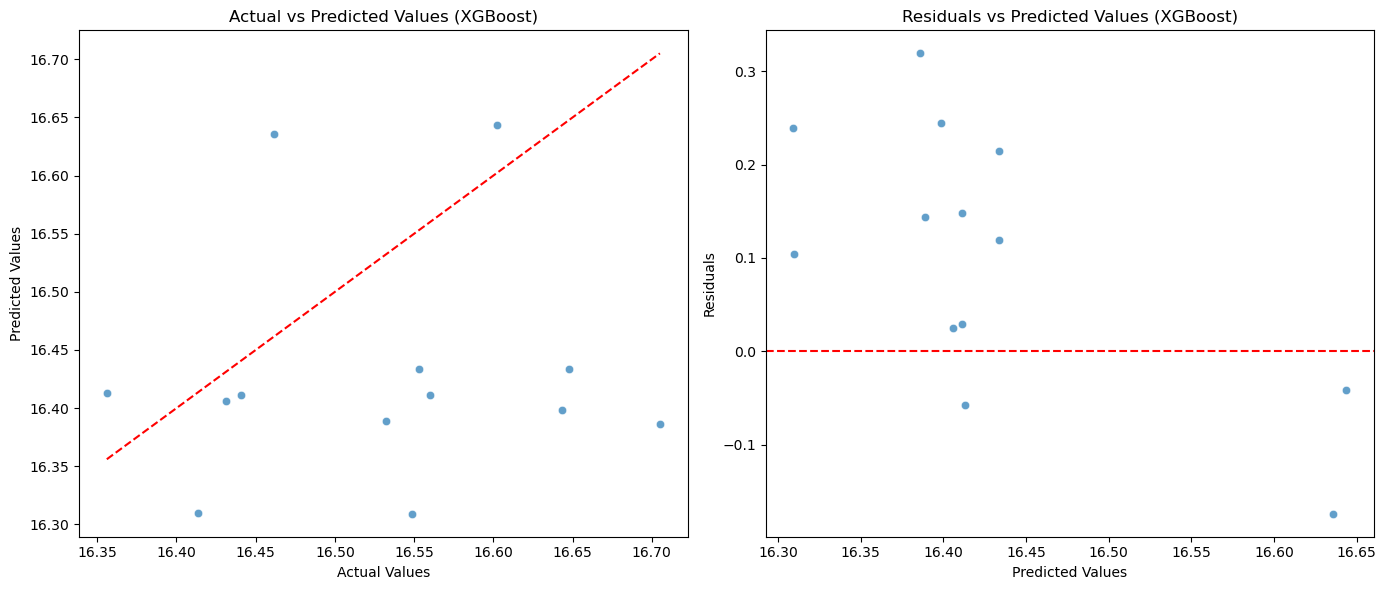

In [255]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Créer des variables retardées (lags) et des indicateurs de tendance
df_lagged = df_log.copy()
for lag in range(1, 6):  # Ajustez le nombre de lags selon vos besoins
    df_lagged[f'lag_{lag}'] = df_lagged['ordered_quantity'].shift(lag)
df_lagged = df_lagged.dropna()

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.6
split_index = int(len(df_lagged) * train_size)
train_data = df_lagged.iloc[:split_index]
test_data = df_lagged.iloc[split_index:]

# Séparer les features et la target
X_train = train_data.drop('ordered_quantity', axis=1)
y_train = train_data['ordered_quantity']
X_test = test_data.drop('ordered_quantity', axis=1)
y_test = test_data['ordered_quantity']

# Créer et ajuster le modèle XGBoost
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150)
model.fit(X_train, y_train)

# Prédictions
predictions = model.predict(X_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Plotting Predictions vs Actual
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values (XGBoost)')

# Plot Residuals
residuals = y_test - predictions
plt.subplot(1, 2, 2)
plt.scatter(predictions, residuals, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values (XGBoost)')

plt.tight_layout()
plt.show()


In [18]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
     -------------------------------------- 124.9/124.9 MB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


MAE: 0.11276352951321081
MSE: 0.018173439528685807
RMSE: 0.13480890003514534
R²: -0.8098623708409014


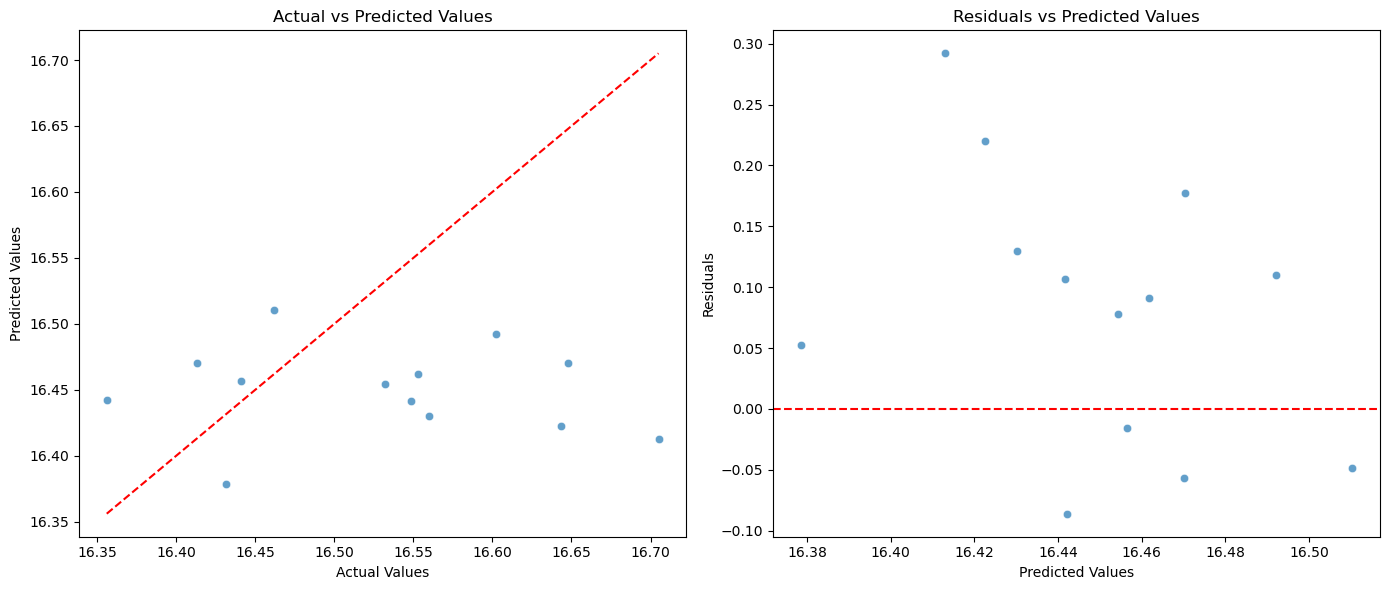

In [256]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Créer et ajuster le modèle Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=1)
model.fit(X_train, y_train)

# Prédictions
predictions = model.predict(X_test)

# Calcul des métriques
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Plotting Predictions vs Actual
plt.figure(figsize=(14, 6))

# Plot Actual vs Predicted
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')

# Plot Residuals
residuals = y_test - predictions
plt.subplot(1, 2, 2)
plt.scatter(predictions, residuals, alpha=0.7, edgecolors='w', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()


Epoch 1/150


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step - loss: 0.3783 - val_loss: 0.3218
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2544 - val_loss: 0.1738
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.1705 - val_loss: 0.0658
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1115 - val_loss: 0.0028
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0932 - val_loss: 0.0245
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0949 - val_loss: 0.0721
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1460 - val_loss: 0.0690
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1264 - val_loss: 0.0388
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1127 - val_loss: 0.0131
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0855 - val_loss: 0.0013
Epoch 11/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0768 - val_loss: 0.0012
Epoch 12/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0677 - val_loss: 0.0079


C:\Users\user\AppData\Local\Temp\ipykernel_40440\2804168064.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['predictions'] = predictions


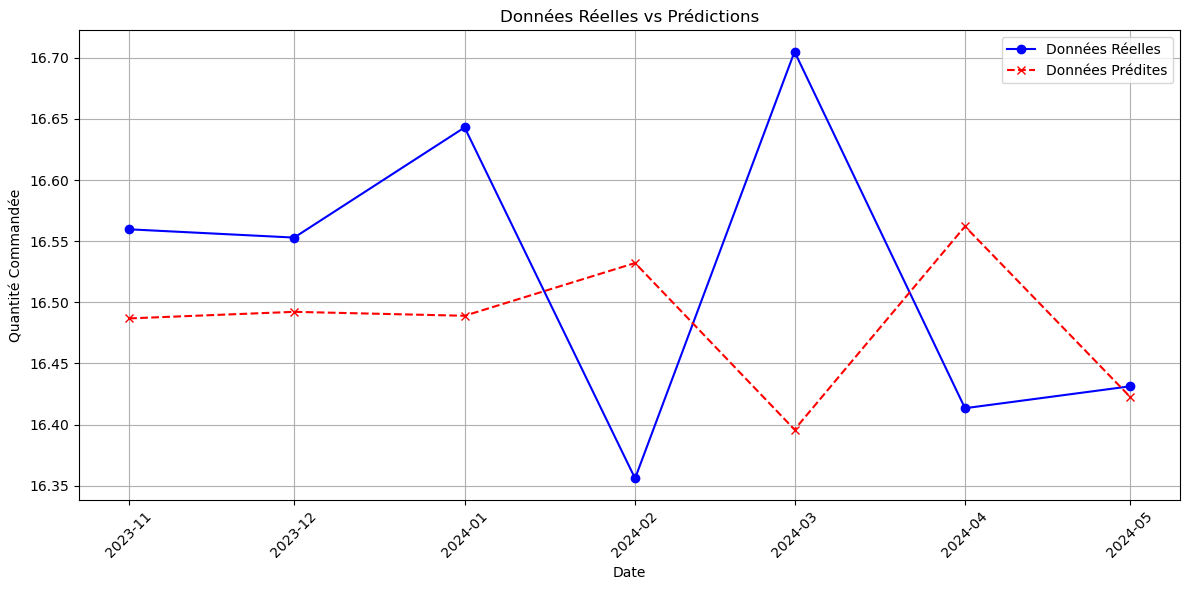

In [279]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Préparation des données
df_lagged = df_log.copy()
for lag in range(1, 2):  # Ajustez le nombre de lags selon vos besoins
    df_lagged[f'lag_{lag}'] = df_lagged['ordered_quantity'].shift(lag)
df_lagged = df_lagged.dropna()

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.8
split_index = int(len(df_lagged) * train_size)
train_data = df_lagged.iloc[:split_index]
test_data = df_lagged.iloc[split_index:]

# Séparer les features et la target
X_train = train_data.drop('ordered_quantity', axis=1)
y_train = train_data['ordered_quantity']
X_test = test_data.drop('ordered_quantity', axis=1)
y_test = test_data['ordered_quantity']

# Normalisation des données
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Création du modèle amélioré
model = Sequential()
model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout pour éviter le surapprentissage
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Couche de sortie

# Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.005), loss='mean_squared_error')

# Entraînement du modèle avec EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train_scaled, epochs=150, batch_size=128, validation_split=0.005, callbacks=[early_stopping], verbose=1)

# Évaluation du modèle
loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f'Loss (MSE): {loss}')

# Prédictions
predictions_scaled = model.predict(X_test_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)

# Calcul des métriques
mae = mean_absolute_error(y_test_unscaled, predictions)
mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_unscaled, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Ajouter la colonne de date pour la visualisation
test_data['predictions'] = predictions

# Tracer les courbes
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, y_test_unscaled, label='Données Réelles', color='blue', linestyle='-', marker='o')
plt.plot(test_data.index, predictions, label='Données Prédites', color='red', linestyle='--', marker='x')
plt.xlabel('Date')
plt.ylabel('Quantité Commandée')
plt.title('Données Réelles vs Prédictions')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Epoch 1/150


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step - loss: 0.1254 - val_loss: 0.0661
Epoch 2/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1561 - val_loss: 0.0338
Epoch 3/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0683 - val_loss: 0.0171
Epoch 4/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1179 - val_loss: 0.0117
Epoch 5/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0970 - val_loss: 0.0104
Epoch 6/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0704 - val_loss: 0.0088
Epoch 7/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0951 - val_loss: 0.0089
Epoch 8/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0815 - val_loss: 0.0098
Epoch 9/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0908 - val_loss: 0.0128
Epoch 10/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0674 - val_loss: 0.0185
Epoch 11/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0943 - val_loss: 0.0265
Epoch 12/150
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0769 - val_loss: 0.0396


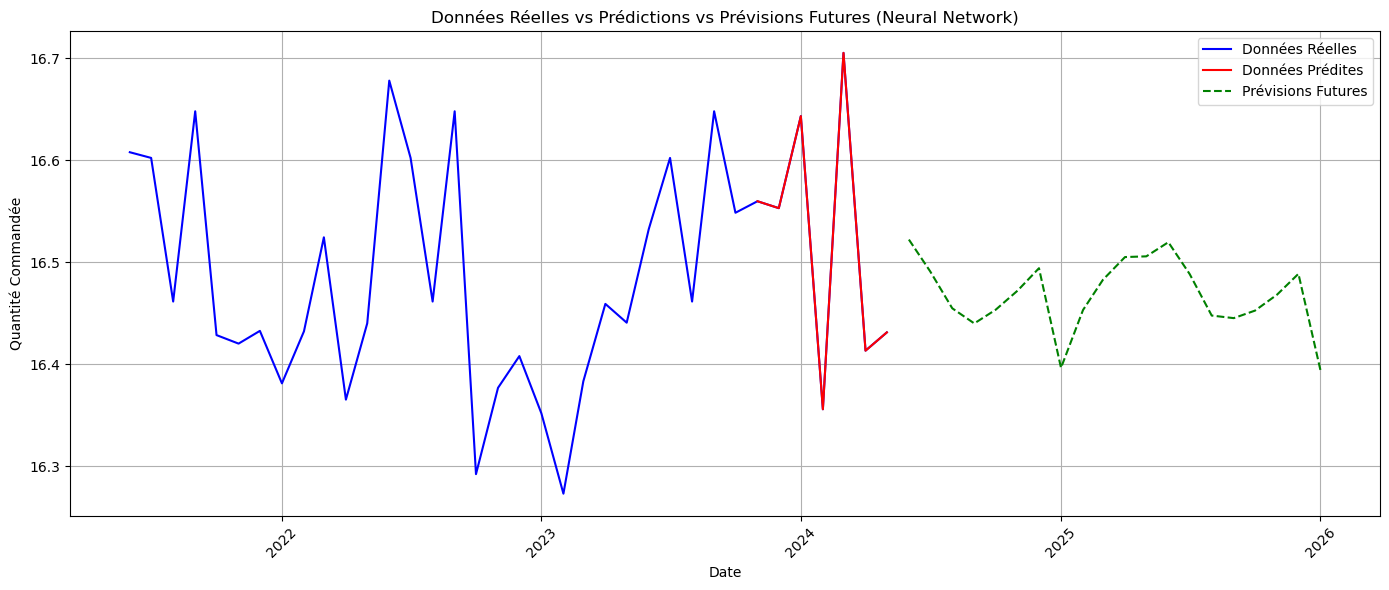

In [277]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Préparation des données
df_lagged = df_log.copy()
for lag in range(1, 6):  # Créer des variables retardées
    df_lagged[f'lag_{lag}'] = df_lagged['ordered_quantity'].shift(lag)

# Ajouter des caractéristiques saisonnières
df_lagged['month'] = df_lagged.index.month
df_lagged['day_of_week'] = df_lagged.index.dayofweek
df_lagged['quarter'] = df_lagged.index.quarter
df_lagged['is_weekend'] = (df_lagged.index.dayofweek >= 5).astype(int)
df_lagged['sin_month'] = np.sin(2 * np.pi * df_lagged.index.month / 12)
df_lagged['cos_month'] = np.cos(2 * np.pi * df_lagged.index.month / 12)
df_lagged['sin_day'] = np.sin(2 * np.pi * df_lagged.index.dayofyear / 365)
df_lagged['cos_day'] = np.cos(2 * np.pi * df_lagged.index.dayofyear / 365)

df_lagged = df_lagged.dropna()  # Supprimer les lignes avec des valeurs manquantes

# Diviser les données en ensembles d'apprentissage et de test
train_size = 0.8
split_index = int(len(df_lagged) * train_size)
train_data = df_lagged.iloc[:split_index]
test_data = df_lagged.iloc[split_index:]

# Séparer les features et la target
X_train = train_data.drop('ordered_quantity', axis=1)
y_train = train_data['ordered_quantity']
X_test = test_data.drop('ordered_quantity', axis=1)
y_test = test_data['ordered_quantity']

# Normalisation des données
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Création du modèle de réseau de neurones avec caractéristiques saisonnières
model = Sequential()
model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.2))  # Dropout pour éviter le surapprentissage
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Couche de sortie

# Compilation du modèle
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Entraînement du modèle avec EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train_scaled, epochs=150, batch_size=128, validation_split=0.005, callbacks=[early_stopping], verbose=1)

# Évaluation du modèle
loss = model.evaluate(X_test_scaled, y_test_scaled, verbose=0)
print(f'Loss (MSE): {loss}')

# Prédictions
predictions_scaled = model.predict(X_test_scaled)
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_unscaled = scaler_y.inverse_transform(y_test_scaled)

# Calcul des métriques
mae = mean_absolute_error(y_test_unscaled, predictions)
mse = mean_squared_error(y_test_unscaled, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_unscaled, predictions)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Préparer les données futures
last_data = df_lagged.iloc[-1:].copy()
future_dates = pd.date_range(start=df_lagged.index[-1] + pd.DateOffset(months=1), periods=20, freq='MS')

# Créer un DataFrame pour les 20 mois à venir
future_df = pd.DataFrame(index=future_dates)
for lag in range(1, 6):
    future_df[f'lag_{lag}'] = last_data[f'lag_{lag}'].values[0]
future_df['month'] = future_df.index.month
future_df['day_of_week'] = future_df.index.dayofweek
future_df['quarter'] = future_df.index.quarter
future_df['is_weekend'] = (future_df.index.dayofweek >= 5).astype(int)
future_df['sin_month'] = np.sin(2 * np.pi * future_df.index.month / 12)
future_df['cos_month'] = np.cos(2 * np.pi * future_df.index.month / 12)
future_df['sin_day'] = np.sin(2 * np.pi * future_df.index.dayofyear / 365)
future_df['cos_day'] = np.cos(2 * np.pi * future_df.index.dayofyear / 365)

# Normaliser les données futures
future_features_scaled = scaler_X.transform(future_df)

# Prédire les 20 mois à venir
future_predictions_scaled = model.predict(future_features_scaled)
future_predictions = scaler_y.inverse_transform(future_predictions_scaled)

# Ajouter les prévisions futures au DataFrame
future_df['forecast'] = future_predictions

# Tracer les courbes
plt.figure(figsize=(14, 6))

# Courbe de la série originale
plt.plot(df_log.index, df_log['ordered_quantity'], label='Données Réelles', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, y_test_unscaled, label='Données Prédites', color='red')

# Courbe des prévisions futures
plt.plot(future_df.index, future_df['forecast'], label='Prévisions Futures', color='green', linestyle='--')

# Ajouter des légendes et des titres
plt.title('Données Réelles vs Prédictions vs Prévisions Futures (Neural Network)')
plt.xlabel('Date')
plt.ylabel('Quantité Commandée')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [104]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('monthly_sum_UL.csv')

# Convert the 'month' column to datetime
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Add 1 month before the first month in the DataFrame
start_date = df['month'].min()
extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')
extra_data = pd.DataFrame({'month': extra_months, 'ordered_quantity': np.nan})
df = pd.concat([extra_data, df])

# Replace outliers
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1 * IQR
    upper_bound = Q3 + 1 * IQR
    df[column] = df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else np.nan)
    return df

df = replace_outliers(df, 'ordered_quantity')

# Compute median for each month
monthly_medians = df.groupby(df['month'].dt.month)['ordered_quantity'].median()

# Function to impute missing values based on month
def impute_missing_values_by_month(df, column):
    df[column] = df.apply(lambda row: monthly_medians[row['month'].month] if pd.isna(row[column]) else row[column], axis=1)
    return df

# Impute missing values
df = impute_missing_values_by_month(df, 'ordered_quantity')

# Save the modified DataFrame
df.to_csv('monthly_sum_UL_modified.csv', index=False)

print(df)

# Read and display the modified file
df_modified = pd.read_csv('monthly_sum_UL_modified.csv', parse_dates=['month'], index_col=['month'])
print(df_modified.head())


        month  ordered_quantity
0  2021-06-30        16317715.5
1  2021-07-31        16227075.0
2  2021-08-31        14097700.0
3  2021-09-30        16985200.0
0  2021-10-01        13641869.0
1  2021-11-01        13528620.0
2  2021-12-01        13698500.0
3  2022-01-01        13012300.0
4  2022-02-01        13692781.0
5  2022-03-01        15013380.0
6  2022-04-01        12806322.0
7  2022-05-01        13799937.0
8  2022-06-01        17503525.0
9  2022-07-01        16227075.0
10 2022-08-01        14097700.0
11 2022-09-01        16985200.0
12 2022-10-01        11905300.0
13 2022-11-01        12955600.0
14 2022-12-01        13364275.0
15 2023-01-01        12635700.0
16 2023-02-01        11679500.0
17 2023-03-01        13038297.0
18 2023-04-01        14065166.0
19 2023-05-01        13808906.0
20 2023-06-01        15131906.0
21 2023-07-01        16227075.0
22 2023-08-01        14097700.0
23 2023-09-01        16985200.0
24 2023-10-01        15378438.0
25 2023-11-01        15552900.0
26 2023-

C:\Users\user\AppData\Local\Temp\ipykernel_40440\4062865774.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  extra_months = pd.date_range(start=start_date - pd.DateOffset(months=4), periods=4, freq='M')


In [112]:
# Mettre la date en index de la table
df.set_index('month',inplace=True)
df


,ordered_quantity
month,
2021-06-30,16317715.5
2021-07-31,16227075.0
2021-08-31,14097700.0
2021-09-30,16985200.0
2021-10-01,13641869.0
2021-11-01,13528620.0
2021-12-01,13698500.0
2022-01-01,13012300.0
2022-02-01,13692781.0


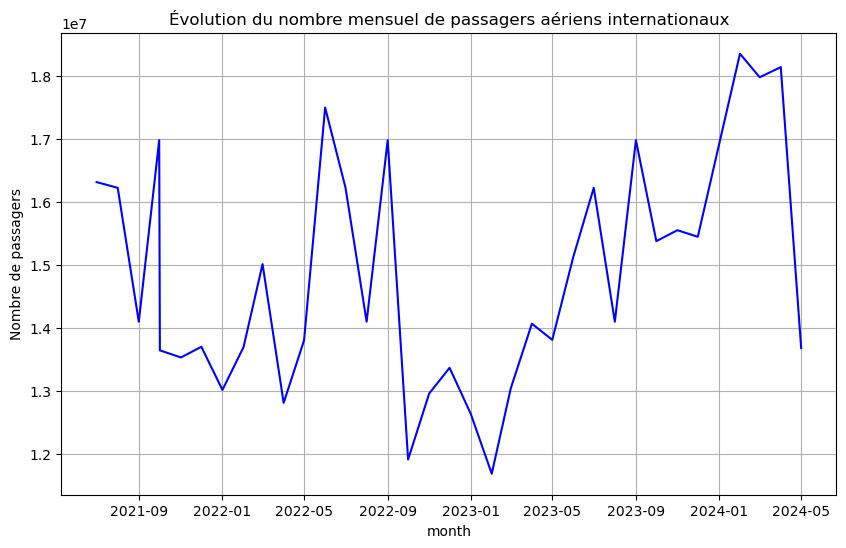

In [113]:
# Créer le graphique
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['ordered_quantity'], color='blue')
plt.title('Évolution du nombre mensuel de passagers aériens internationaux')
plt.xlabel('month')
plt.ylabel('Nombre de passagers')
plt.grid(True)
plt.show()

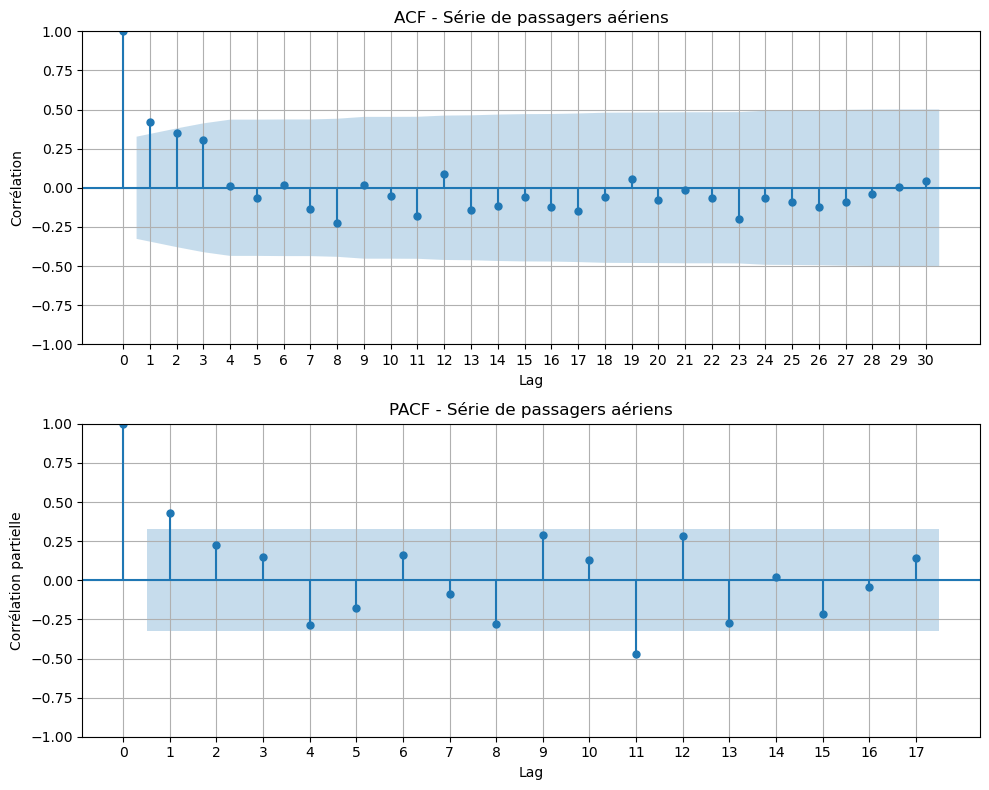

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Determine the number of observations
n_obs = len(df['ordered_quantity'])

# Set the number of lags for PACF to be less than 50% of the number of observations
lags_pacf = min(30, n_obs // 2 - 1)

# Create the subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot ACF
plot_acf(df['ordered_quantity'], lags=30, zero=True, ax=ax1)
ax1.set_title('ACF - Série de passagers aériens')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Corrélation')
ax1.grid(True)

# Adjust x-axis ticks for ACF
ax1.set_xticks(np.arange(0, 31, 1))

# Plot PACF with adjusted lags
plot_pacf(df['ordered_quantity'], lags=lags_pacf, zero=True, ax=ax2)
ax2.set_title('PACF - Série de passagers aériens')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Corrélation partielle')
ax2.grid(True)

# Adjust x-axis ticks for PACF
ax2.set_xticks(np.arange(0, lags_pacf + 1, 1))

# Adjust subplots
plt.tight_layout()

# Show the plot
plt.show()


In [118]:
# Analyse de la stationnarité de la variable
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

# Effectuer le test de Dickey-Fuller augmenté
result = adfuller(df)

# Formater les résultats dans un tableau
table = [
    ['Valeur de test', result[0]],
    ['P-valeur', result[1]],
    ['Conclusion', 'La série est stationnaire' if result[1] < 0.05 else 'La série est non stationnaire']
]

# Afficher les résultats sous forme de tableau
print(tabulate(table, headers=['Métrique', 'Valeur'], tablefmt='github'))

| Métrique       | Valeur                    |
|----------------|---------------------------|
| Valeur de test | -3.672098484125839        |
| P-valeur       | 0.004523177219871322      |
| Conclusion     | La série est stationnaire |


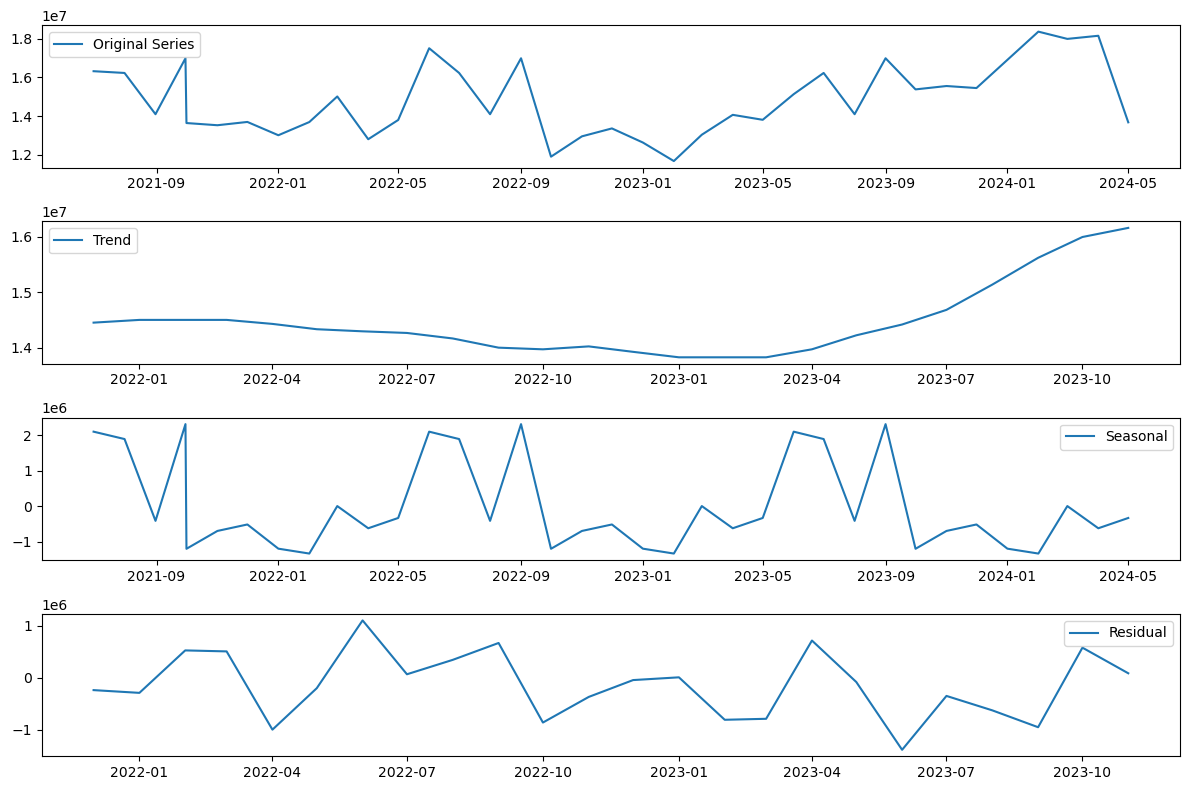

In [122]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Specify period (e.g., 12 for monthly data with annual seasonality)
decomposition = seasonal_decompose(df['ordered_quantity'], model='additive', period=12)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['ordered_quantity'], label='Original Series')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='best')

plt.tight_layout()
plt.show()


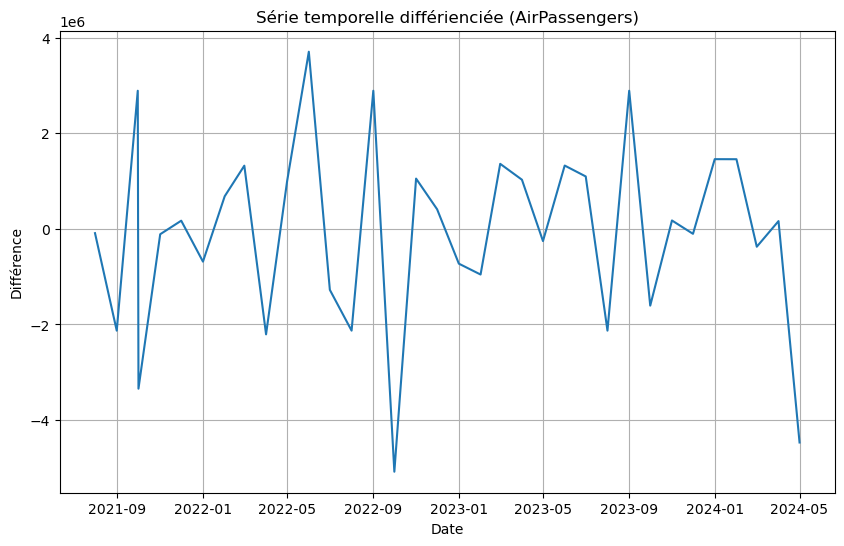

In [123]:
# Différenciation pour rendre la série stationnaire
differenced = df['ordered_quantity'].diff().dropna()

# Afficher la série différienciée
plt.figure(figsize=(10, 6))
plt.plot(differenced)
plt.title('Série temporelle différienciée (AirPassengers)')
plt.xlabel('Date')
plt.ylabel('Différence')
plt.grid(True)
plt.show()

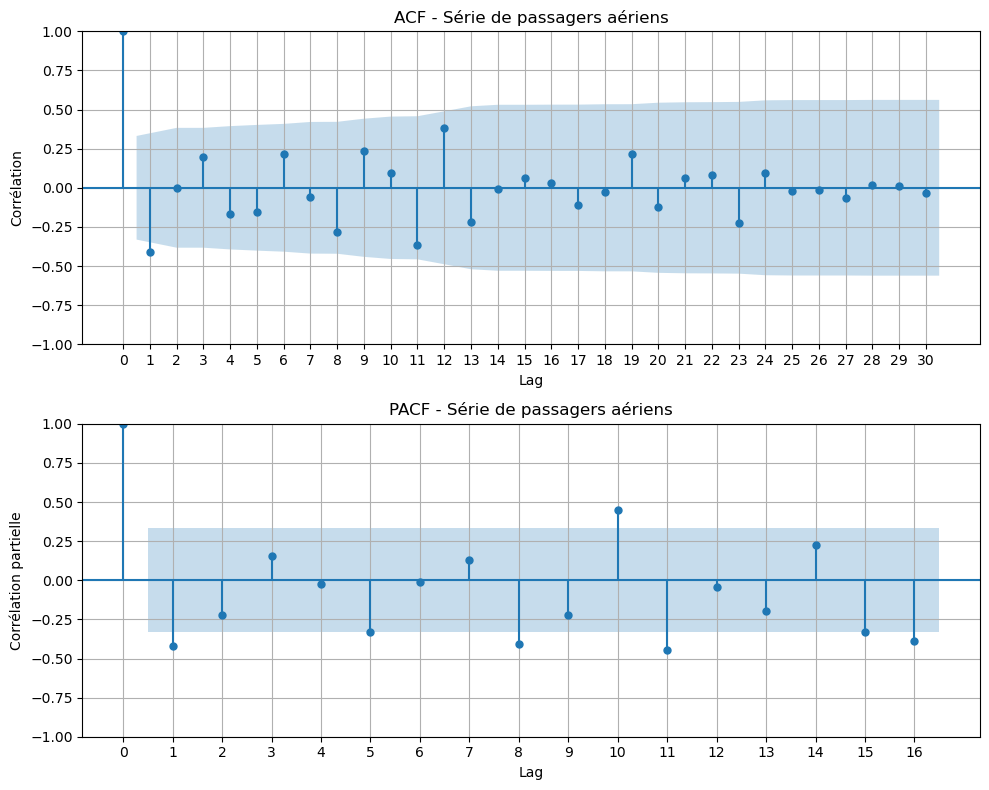

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Determine the sample size of the differenced time series
n_obs_differenced = len(differenced)

# Set the number of lags for PACF to be less than 50% of the number of observations
lags_pacf = min(30, n_obs_differenced // 2 - 1)

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot ACF
plot_acf(differenced, lags=30, zero=True, ax=ax1)
ax1.set_title('ACF - Série de passagers aériens')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Corrélation')
ax1.grid(True)

# Adjust x-axis ticks for ACF
ax1.set_xticks(np.arange(0, 31, 1))

# Plot PACF with adjusted lags
plot_pacf(differenced, lags=lags_pacf, zero=True, ax=ax2)
ax2.set_title('PACF - Série de passagers aériens')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Corrélation partielle')
ax2.grid(True)

# Adjust x-axis ticks for PACF
ax2.set_xticks(np.arange(0, lags_pacf + 1, 1))

# Adjust subplots
plt.tight_layout()

# Show the plot
plt.show()


In [127]:
# Analyse de la stationnarité de la variable
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

# Effectuer le test de Dickey-Fuller augmenté
result = adfuller(differenced)

# Formater les résultats dans un tableau
table = [
    ['Valeur de test', result[0]],
    ['P-valeur', result[1]],
    ['Conclusion', 'La série est stationnaire' if result[1] < 0.05 else 'La série est non stationnaire']
]

# Afficher les résultats sous forme de tableau
print(tabulate(table, headers=['Métrique', 'Valeur'], tablefmt='github'))

| Métrique       | Valeur                    |
|----------------|---------------------------|
| Valeur de test | -8.638395866577085        |
| P-valeur       | 5.510461896960893e-14     |
| Conclusion     | La série est stationnaire |


In [128]:
p=1
d=0
q=1

In [154]:
# Déterminez la taille de l'ensemble de test (30 % des dernières données)
test_size = int(len(df) * 0.20)

# Séparer les données en ensemble d'entraînement et ensemble de test
train_data = df['ordered_quantity'][:-test_size]
test_data = df['ordered_quantity'][-test_size:]

In [228]:
from statsmodels.tsa.arima.model import ARIMA

# Créer un modèle ARIMA(2,1,1)
model = ARIMA(train_data, order=(6,0,5))

# Ajuster le modèle
model_fit = model.fit()

# Afficher le résumé du modèle
print(model_fit.summary())

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:       ordered_quantity   No. Observations:                   29
Model:                 ARIMA(6, 0, 5)   Log Likelihood                -443.733
Date:                Sun, 11 Aug 2024   AIC                            913.467
Time:                        12:23:46   BIC                            931.242
Sample:                             0   HQIC                           919.034
                                 - 29                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.445e+07   2.25e-06   6.42e+12      0.000    1.44e+07    1.44e+07
ar.L1         -0.1006      0.650     -0.155      0.877      -1.374       1.172
ar.L2          0.4399      0.223      1.971      0.0

<Figure size 1000x500 with 0 Axes>

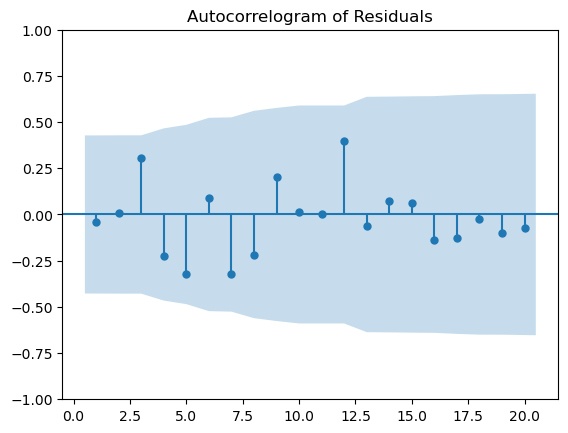

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


<Figure size 1000x500 with 0 Axes>

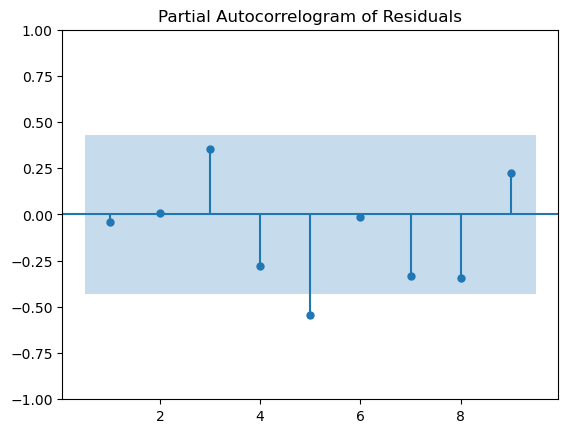

In [229]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Calculate the number of observations in residuals
n_residuals = len(residuals)

# Set the number of lags for ACF and PACF
max_lags_acf = min(30, n_residuals - 1)
max_lags_pacf = min(max_lags_acf, n_residuals // 2 - 1)

# Plot ACF of residuals
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=max_lags_acf, zero=False)
plt.title("Autocorrelogram of Residuals")
plt.show()

# Plot PACF of residuals with adjusted number of lags
plt.figure(figsize=(10, 5))
plot_pacf(residuals, lags=max_lags_pacf, zero=False)
plt.title("Partial Autocorrelogram of Residuals")
plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Training MAE: 903220.63, MSE: 1222208463575.09, R2: 0.53
Test MAE: 3072657.10, MSE: 13274972844324.03, R2: -4.03


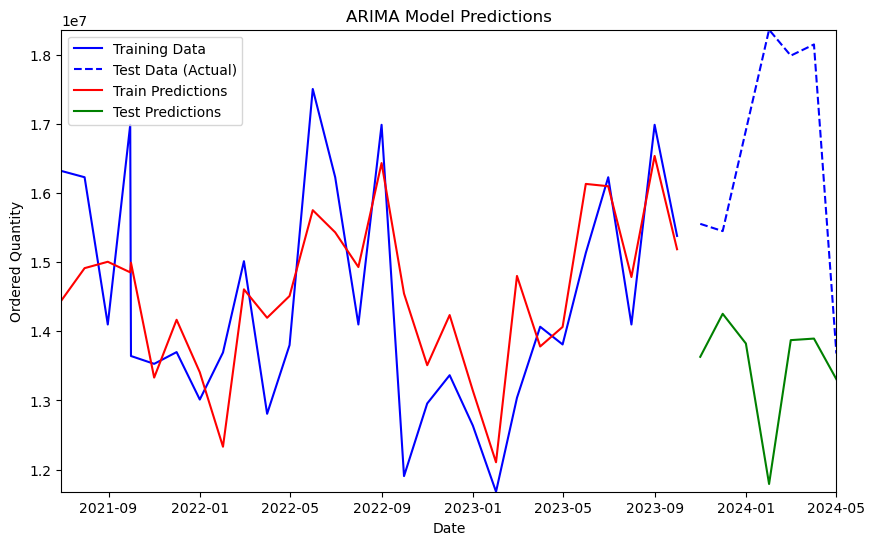

In [230]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Assurez-vous que les indices sont au format datetime
train_data.index = pd.to_datetime(train_data.index)
test_data.index = pd.to_datetime(test_data.index)

# Utiliser get_forecast pour les prédictions sur l'ensemble de test
train_predictions = model_fit.get_prediction(start=train_data.index[0], end=train_data.index[-1])
test_forecast = model_fit.get_forecast(steps=len(test_data))

# Extraire les valeurs prédites
train_pred_mean = train_predictions.predicted_mean
test_pred_mean = test_forecast.predicted_mean

# Calculer les métriques pour les données d'entraînement
mae_train = mean_absolute_error(train_data, train_pred_mean)
mse_train = mean_squared_error(train_data, train_pred_mean)
r2_train = r2_score(train_data, train_pred_mean)

# Calculer les métriques pour les données de test
mae_test = mean_absolute_error(test_data, test_pred_mean)
mse_test = mean_squared_error(test_data, test_pred_mean)
r2_test = r2_score(test_data, test_pred_mean)

print(f'Training MAE: {mae_train:.2f}, MSE: {mse_train:.2f}, R2: {r2_train:.2f}')
print(f'Test MAE: {mae_test:.2f}, MSE: {mse_test:.2f}, R2: {r2_test:.2f}')

# Visualiser les résultats
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data.values, label='Training Data', color='blue')
plt.plot(test_data.index, test_data.values, label='Test Data (Actual)', color='blue', linestyle='--')
plt.plot(train_data.index, train_pred_mean, label='Train Predictions', color='red')
plt.plot(test_data.index, test_pred_mean, label='Test Predictions', color='green')

# Définir les limites des axes pour une meilleure visualisation
plt.xlim(train_data.index[0], test_data.index[-1])
plt.ylim(min(train_data.min(), test_data.min()), max(train_data.max(), test_data.max()))

plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.title('ARIMA Model Predictions')
plt.legend()
plt.show()


In [231]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assurez-vous que les indices sont au format datetime
train_data.index = pd.to_datetime(train_data.index)
test_data.index = pd.to_datetime(test_data.index)

# Utiliser get_forecast pour les prédictions sur l'ensemble de test
train_predictions = model_fit.get_prediction(start=train_data.index[0], end=train_data.index[-1])
test_forecast = model_fit.get_forecast(steps=len(test_data))

# Extraire les valeurs prédites
train_pred_mean = train_predictions.predicted_mean
test_pred_mean = test_forecast.predicted_mean

# Mesures de performance sur l'ensemble d'entraînement
train_mae = mean_absolute_error(train_data, train_pred_mean)
train_mse = mean_squared_error(train_data, train_pred_mean)
train_rmse = mean_squared_error(train_data, train_pred_mean, squared=False)
train_r2 = r2_score(train_data, train_pred_mean)

# Mesures de performance sur l'ensemble de test
test_mae = mean_absolute_error(test_data, test_pred_mean)
test_mse = mean_squared_error(test_data, test_pred_mean)
test_rmse = mean_squared_error(test_data, test_pred_mean, squared=False)
test_r2 = r2_score(test_data, test_pred_mean)

# Créer un DataFrame pour afficher les mesures de performance
performance_df = pd.DataFrame({
    'Métrique': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Ensemble d\'entraînement': [train_mae, train_mse, train_rmse, train_r2],
    'Ensemble de test': [test_mae, test_mse, test_rmse, test_r2]
})

print(performance_df)


  Métrique  Ensemble d'entraînement  Ensemble de test
0      MAE             9.032206e+05      3.072657e+06
1      MSE             1.222208e+12      1.327497e+13
2     RMSE             1.105535e+06      3.643484e+06
3       R²             5.262910e-01     -4.033589e+00


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [237]:
#!pip install pmdarima

import pmdarima as pm

# Déterminez la taille de l'ensemble de test (30 % des dernières données)
test_size = int(len(df) * 0.30)

# Séparer les données en ensemble d'entraînement et ensemble de test
train_data = df['ordered_quantity'][:-test_size]
test_data = df['ordered_quantity'][-test_size:]

# Utiliser auto_arima pour trouver le meilleur modèle ARIMA
model = pm.auto_arima(train_data)

print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   26
Model:                        SARIMAX   Log Likelihood                -408.402
Date:                Sun, 11 Aug 2024   AIC                            820.804
Time:                        12:26:30   BIC                            823.320
Sample:                             0   HQIC                           821.528
                                 - 26                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   1.432e+07   3.48e+05     41.121      0.000    1.36e+07     1.5e+07
sigma2      2.577e+12   1.06e+12      2.437      0.015    5.04e+11    4.65e+12
Ljung-Box (L1) (Q):                   1.57   Jarque-

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


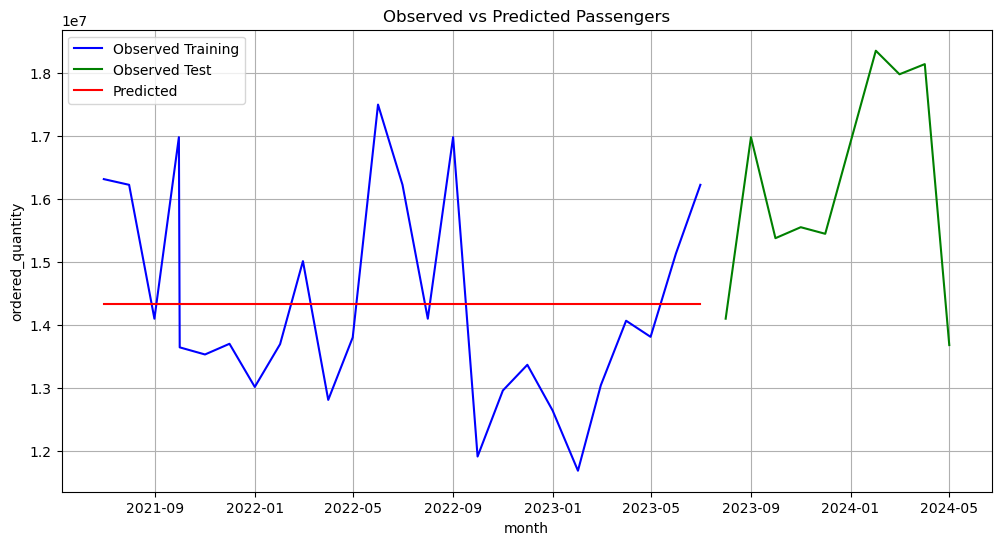

In [238]:

# Faire des prédictions sur l'ensemble d'entraînement
train_pred, train_confint = model.predict_in_sample(return_conf_int=True)

# Faire des prédictions sur l'ensemble de test
n_periods = len(test_data)
predicted, confint = model.predict(n_periods=n_periods, return_conf_int=True)

# Concaténer les prédictions pour l'ensemble d'entraînement et de test
all_predictions = pd.concat([pd.Series(train_pred, index=train_data.index), 
                             pd.Series(predicted, index=test_data.index)], 
                            axis=0)

# Tracer les valeurs réelles et les prédictions pour l'ensemble d'entraînement et de test
plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Observed Training', color='blue')
plt.plot(test_data, label='Observed Test', color='green')
plt.plot(all_predictions, label='Predicted', color='red')

plt.xlabel('month')
plt.ylabel('ordered_quantity')
plt.title('Observed vs Predicted Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [239]:
# Calculer les mesures de performance sur l'ensemble d'entraînement
train_mae = mean_absolute_error(train_data, train_pred)
train_mse = mean_squared_error(train_data, train_pred)
train_rmse = mean_squared_error(train_data, train_pred, squared=False)
train_r2 = r2_score(train_data, train_pred)

# Calculer les mesures de performance sur l'ensemble de test
test_mae = mean_absolute_error(test_data, predicted)
test_mse = mean_squared_error(test_data, predicted)
test_rmse = mean_squared_error(test_data, predicted, squared=False)
test_r2 = r2_score(test_data, predicted)

# Créer un DataFrame pour afficher les mesures de performance
performance_df = pd.DataFrame({
    'Métrique': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Ensemble d\'entraînement': [train_mae, train_mse, train_rmse, train_r2],
    'Ensemble de test': [test_mae, test_mse, test_rmse, test_r2]
})

print(performance_df)

  Métrique  Ensemble d'entraînement  Ensemble de test
0      MAE             1.361102e+06      2.103651e+06
1      MSE             2.577025e+12      6.237318e+12
2     RMSE             1.605311e+06      2.497462e+06
3       R²             0.000000e+00     -1.478421e+00


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
